# Walmart Sales Analysis — Exploratory Data Analysis

## Project Overview

This notebook performs exploratory data analysis (EDA) on Walmart historical sales data to identify sales patterns, evaluate data quality, investigate unusual observations, and explore relationships between weekly sales and store, economic, and promotional factors.

### Objectives
- Inspect and validate the datasets
- Analyze sales trends over time
- Compare store and department performance
- Examine holiday and non-holiday sales patterns
- Investigate sales distributions and outliers
- Explore relationships with store size and economic variables
- Assess promotional Markdown data
- Identify departments with high sales variability

### Tools
**Python | Pandas | NumPy | Matplotlib | Seaborn**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

## 2. Load Datasets

The Walmart dataset consists of three main files used in this analysis:

- **Train:** Historical department-level weekly sales data
- **Features:** External and economic variables such as temperature, fuel price, CPI, unemployment, and promotional markdowns
- **Stores:** Store-level information including store type and size

In [2]:
train=pd.read_csv(r"D:\SQL\Walmart_Sales_Analytics\Data\train.csv")
features=pd.read_csv(r"D:\SQL\Walmart_Sales_Analytics\Data\features.csv")
stores=pd.read_csv(r"D:\SQL\Walmart_Sales_Analytics\Data\stores.csv")

## 3. Initial Data Inspection

The datasets are initially examined to understand their dimensions, structure, columns, data types, and summary statistics.

In [3]:
print("Train:",train.shape)
print("Features:",features.shape)
print("Stores:",stores.shape)

Train: (421570, 8)
Features: (8190, 12)
Stores: (45, 3)


In [4]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Month_Name
0,1,1,2010-02-05,24924.50,0,2010,2,February
1,1,1,2010-02-12,46039.49,1,2010,2,February
2,1,1,2010-02-19,41595.55,0,2010,2,February
3,1,1,2010-02-26,19403.54,0,2010,2,February
4,1,1,2010-03-05,21827.90,0,2010,3,March


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  int64  
 5   Year          421570 non-null  int64  
 6   Month         421570 non-null  int64  
 7   Month_Name    421570 non-null  object 
dtypes: float64(1), int64(5), object(2)
memory usage: 25.7+ MB


In [6]:
train.describe()

,Store,Dept,Weekly_Sales,IsHoliday,Year,Month
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,0.070358,2010.968591,6.449510
std,12.785297,30.492054,22711.183519,0.255750,0.796876,3.243217
min,1.000000,1.000000,-4988.940000,0.000000,2010.000000,1.000000
25%,11.000000,18.000000,2079.650000,0.000000,2010.000000,4.000000
50%,22.000000,37.000000,7612.030000,0.000000,2011.000000,6.000000
75%,33.000000,74.000000,20205.852500,0.000000,2012.000000,9.000000
max,45.000000,99.000000,693099.360000,1.000000,2012.000000,12.000000


In [7]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [8]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [9]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [10]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [11]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [12]:
stores["Type"].value_counts()

Type
A    22
B    17
C     6
Name: count, dtype: int64

## 4. Data Quality Assessment

Before performing the analysis, the datasets are checked for missing values, duplicate records, data-type issues, and unusual sales observations such as negative and zero Weekly Sales.

In [13]:
print("TRAIN MISSING VALUES")
print(train.isnull().sum())

print("\nFEATURES MISSING VALUES")
print(features.isnull().sum())

print("\nSTORES MISSING VALUES")
print(stores.isnull().sum())

TRAIN MISSING VALUES
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Year            0
Month           0
Month_Name      0
dtype: int64

FEATURES MISSING VALUES
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

STORES MISSING VALUES
Store    0
Type     0
Size     0
dtype: int64


In [14]:
print("TRAIN DUPLICATED VALUES")
print(train.duplicated().sum())

print("\nFEATURES DUPLICATED VALUES")
print(features.duplicated().sum())

print("\nSTORES DUPLICATED VALUES")
print(stores.duplicated().sum())

TRAIN DUPLICATED VALUES
0

FEATURES DUPLICATED VALUES
0

STORES DUPLICATED VALUES
0


In [15]:
print("Train rows:",len(train))
print("Features rows:",len(features))
print("Stores rows:",len(stores))

Train rows: 421570
Features rows: 8190
Stores rows: 45


In [16]:
print("TRAIN")
print(train.dtypes)

print("\nFEATURES")
print(features.dtypes)

print("\nSTORES")
print(stores.dtypes)

TRAIN
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday         int64
Year              int64
Month             int64
Month_Name       object
dtype: object

FEATURES
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

STORES
Store     int64
Type     object
Size      int64
dtype: object


In [17]:
print("Number of Stores:", train["Store"].nunique())
print("Number of Departments:", train["Dept"].nunique())

Number of Stores: 45
Number of Departments: 81


In [18]:
print("Store IDs:")
print(sorted(train["Store"].unique()))

print("\nDepartment IDs:")
print(sorted(train["Dept"].unique()))



Store IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45)]

Department IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64

In [19]:
print("Earliest Date:", train["Date"].min())
print("Latest Date:", train["Date"].max())

Earliest Date: 2010-02-05
Latest Date: 2012-10-26


In [20]:
train["Date"].str[:4].value_counts().sort_index()

Date
2010    140679
2011    153453
2012    127438
Name: count, dtype: int64

In [21]:
train["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [22]:
print("Minimum Sales:",train["Weekly_Sales"].min())
print("Maximum Sales:",train["Weekly_Sales"].max())
print("Average Sales:",train["Weekly_Sales"].mean())
print("Median Sales:",train["Weekly_Sales"].median())

Minimum Sales: -4988.94
Maximum Sales: 693099.36
Average Sales: 15981.258123467042
Median Sales: 7612.03


In [23]:
print("Negative Sales:", (train["Weekly_Sales"]<0).sum())
print("Zero Sales:", (train["Weekly_Sales"]==0).sum())

Negative Sales: 1285
Zero Sales: 73


In [24]:
negative_sales=train[train["Weekly_Sales"]<0]
negative_sales.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Month_Name
846,1,6,2012-08-10,-139.65,0,2012,8,August
2384,1,18,2012-05-04,-1.27,0,2012,5,May
6048,1,47,2010-02-19,-863.00,0,2010,2,February
6049,1,47,2010-03-12,-698.00,0,2010,3,March
6051,1,47,2010-10-08,-58.00,0,2010,10,October
6056,1,47,2011-04-08,-298.00,0,2011,4,April
6057,1,47,2011-07-08,-198.00,0,2011,7,July
6061,1,47,2011-10-14,-498.00,0,2011,10,October
6062,1,47,2011-12-23,-498.00,0,2011,12,December
6063,1,47,2012-02-17,-198.00,0,2012,2,February


In [25]:
negative_sales[["Store","Dept","Date","Weekly_Sales"]]

,Store,Dept,Date,Weekly_Sales
846,1,6,2012-08-10,-139.65
2384,1,18,2012-05-04,-1.27
6048,1,47,2010-02-19,-863.00
6049,1,47,2010-03-12,-698.00
6051,1,47,2010-10-08,-58.00
...,...,...,...,...
419597,45,80,2010-02-12,-0.43
419598,45,80,2010-02-19,-0.27
419603,45,80,2010-04-16,-1.61
419614,45,80,2010-07-02,-0.27


In [26]:
negative_sales["Store"].value_counts().head(10)

Store
35    124
18     52
10     50
17     49
15     45
42     44
22     41
31     39
20     38
16     38
Name: count, dtype: int64

In [27]:
negative_sales["Dept"].value_counts().head(10)

Dept
47    254
18    180
54    146
19     87
94     77
80     68
49     67
59     44
72     34
78     33
Name: count, dtype: int64

In [28]:
negative_sales.groupby("Dept")["Weekly_Sales"].agg(
    ["count","min","max","sum"]
    ).sort_values("count",ascending=False).head(10)


,count,min,max,sum
Dept,,,,
47,254,-3924.00,-1.50,-53188.06
18,180,-175.54,-0.10,-1819.05
54,146,-465.08,-0.76,-4829.81
19,87,-69.56,-0.97,-1042.66
94,77,-173.84,-0.08,-647.78
80,68,-590.04,-0.04,-4231.48
49,67,-326.61,-1.88,-1455.98
59,44,-55.46,-0.36,-411.82
72,34,-379.00,-5.00,-3047.58


In [29]:
zero_sales=train[train["Weekly_Sales"]==0]
zero_sales.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Month_Name
6055,1,47,2011-03-11,0.0,0,2011,3,March
6059,1,47,2011-08-12,0.0,0,2011,8,August
6060,1,47,2011-08-19,0.0,0,2011,8,August
16309,2,47,2012-04-13,0.0,0,2012,4,April
17457,2,60,2010-03-19,0.0,0,2010,3,March
25448,3,36,2012-08-17,0.0,0,2012,8,August
56663,6,78,2010-02-26,0.0,0,2010,2,February
64921,7,49,2011-06-17,0.0,0,2011,6,June
65215,7,54,2011-01-21,0.0,0,2011,1,January
76467,8,78,2011-08-26,0.0,0,2011,8,August


In [30]:
zero_sales["Dept"].value_counts().head(10)

Dept
47    19
54    13
78    10
51     4
60     3
48     3
49     2
98     2
19     2
32     2
Name: count, dtype: int64

## 5. Date Preparation & Feature Engineering

The Date column is converted to datetime format to support time-based analysis. Additional Year, Month, and Month Name features are created to examine sales patterns across different time periods.

In [31]:
train["Date"]=pd.to_datetime(train["Date"])
features["Date"]=pd.to_datetime(features["Date"])

In [32]:
print(train["Date"].dtype)
print(features["Date"].dtype)

datetime64[ns]
datetime64[ns]


In [33]:
print(train[["Date"]].head())
print(train["Date"].min())
print(train["Date"].max())

        Date
0 2010-02-05
1 2010-02-12
2 2010-02-19
3 2010-02-26
4 2010-03-05
2010-02-05 00:00:00
2012-10-26 00:00:00


In [34]:
train["Year"]=train["Date"].dt.year
train["Month"]=train["Date"].dt.month
train["Month_Name"]=train["Date"].dt.month_name()

In [35]:
train[["Date","Year","Month","Month_Name"]].head()

,Date,Year,Month,Month_Name
0,2010-02-05,2010,2,February
1,2010-02-12,2010,2,February
2,2010-02-19,2010,2,February
3,2010-02-26,2010,2,February
4,2010-03-05,2010,3,March


## 6. Exploratory Sales Analysis

This section explores the main sales patterns in the dataset, including yearly and monthly trends, store and department performance, and differences between holiday and non-holiday periods.

### 6.1 Yearly Sales Trend

In [36]:
yearly_sales=train.groupby(
    train["Date"].dt.to_period("Y")
)["Weekly_Sales"].sum()

yearly_sales

Date
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Freq: Y-DEC, Name: Weekly_Sales, dtype: float64

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

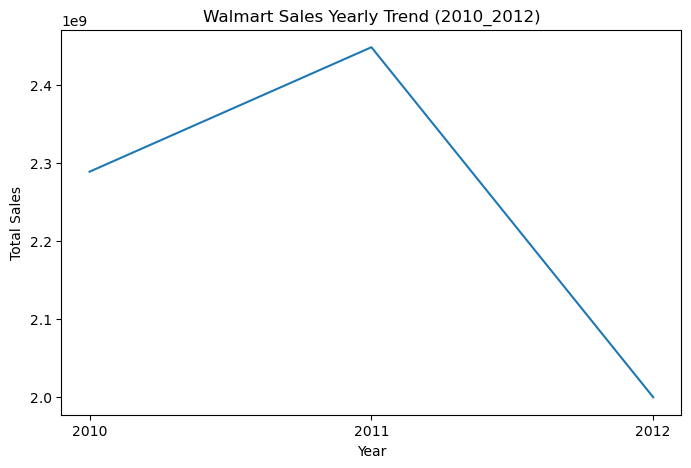

In [38]:
plt.figure(figsize=(8,5))

plt.plot(yearly_sales.index.astype(str),yearly_sales.values)
plt.title("Walmart Sales Yearly Trend (2010_2012)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

Observation: Total sales increased from approximately 2.29 billion dollars in 2010 to 2.45 billion dollars in 2011, indicating growth in annual sales. Sales recorded for 2012 were approximately 2.00 billion dollars; however, the dataset only extends through October 2012, so the 2012 total should not be directly compared with the complete previous years.

### 6.2 Monthly Sales Trend

In [39]:
train["Date"] = pd.to_datetime(train["Date"])

monthly_sales = train.groupby(
    train["Date"].dt.to_period("M")
)["Weekly_Sales"].sum()
monthly_sales

Date
2010-02    1.903330e+08
2010-03    1.819198e+08
2010-04    2.314124e+08
2010-05    1.867109e+08
2010-06    1.922462e+08
2010-07    2.325801e+08
2010-08    1.876401e+08
2010-09    1.772679e+08
2010-10    2.171618e+08
2010-11    2.028534e+08
2010-12    2.887605e+08
2011-01    1.637040e+08
2011-02    1.863313e+08
2011-03    1.793564e+08
2011-04    2.265265e+08
2011-05    1.816482e+08
2011-06    1.897734e+08
2011-07    2.299114e+08
2011-08    1.885993e+08
2011-09    2.208477e+08
2011-10    1.832613e+08
2011-11    2.101624e+08
2011-12    2.880781e+08
2012-01    1.688945e+08
2012-02    1.920636e+08
2012-03    2.315097e+08
2012-04    1.889209e+08
2012-05    1.887665e+08
2012-06    2.406103e+08
2012-07    1.875095e+08
2012-08    2.368508e+08
2012-09    1.806455e+08
2012-10    1.843617e+08
Freq: M, Name: Weekly_Sales, dtype: float64

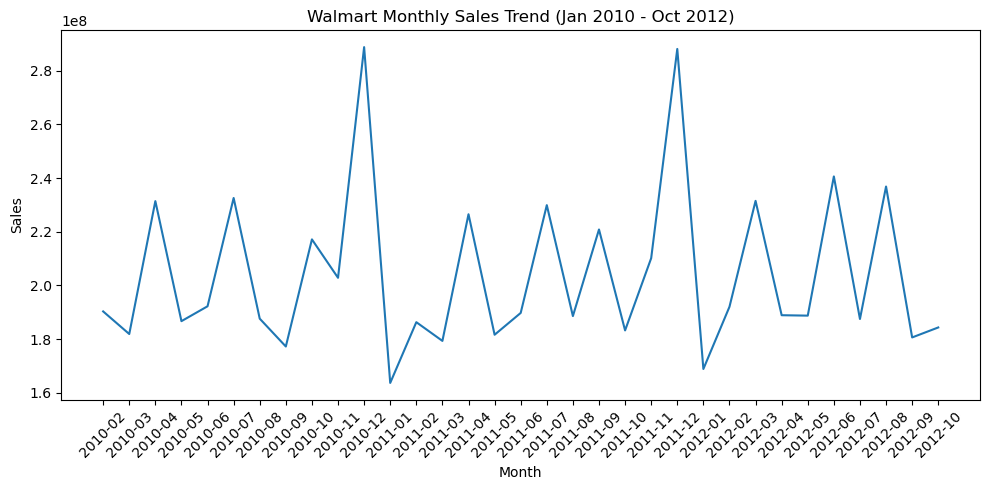

In [40]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Walmart Monthly Sales Trend (Jan 2010 - Oct 2012)")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: Monthly sales show noticeable seasonal variation across the dataset. December recorded particularly high sales in the complete years 2010 and 2011, suggesting stronger sales activity toward the end of the year. The 2012 monthly pattern should be interpreted cautiously because the dataset ends in October 2012.

### 6.3 Top 10 Stores by Total Sales

In [41]:
sales_by_stores=train.groupby("Store")["Weekly_Sales"].sum()

In [42]:
sales_by_stores.sort_values(ascending=False).head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

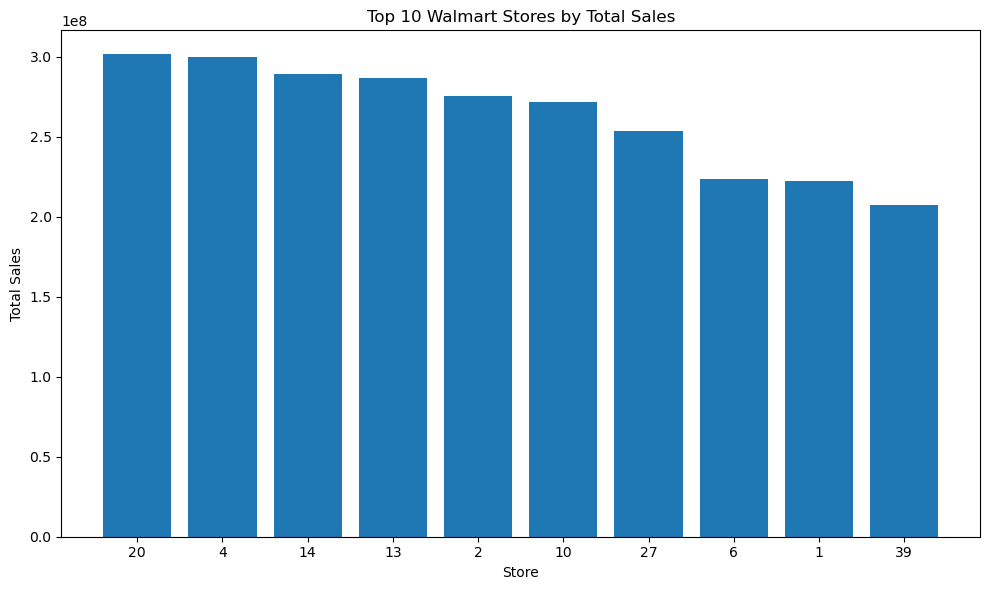

In [43]:
top_10_stores = sales_by_stores.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_stores.index.astype(str),
    top_10_stores.values
)

plt.title("Top 10 Walmart Stores by Total Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.show()

Observation: Sales performance varies considerably among the highest-performing Walmart stores. Store 20 generated the highest total sales, followed closely by Store 4 and Store 14. The concentration of high sales among certain stores suggests that store-level characteristics and local demand may contribute to differences in performance. Further analysis would be required to determine the specific factors behind these differences.

### 6.4 Top 10 Departments by Total Sales

In [44]:
sales_by_department=train.groupby("Dept")["Weekly_Sales"].sum()

In [45]:
sales_by_department.sort_values(ascending=False).head(10)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

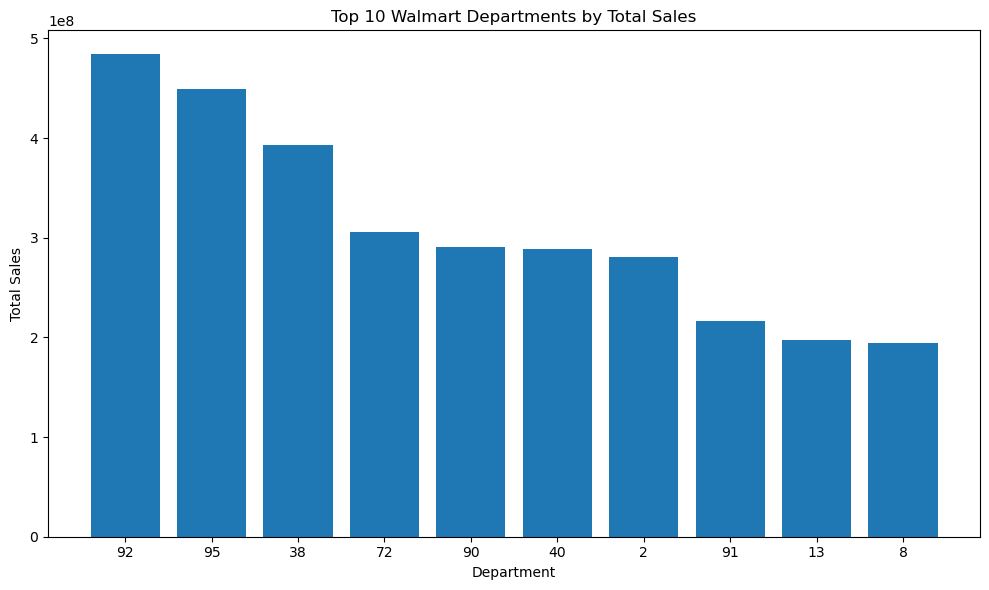

In [46]:
top_10_departments = sales_by_department.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_departments.index.astype(str),
    top_10_departments.values
)

plt.title("Top 10 Walmart Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.show()

Observation: Department 92 generated the highest total sales, followed by Departments 95 and 38. The results show that sales are concentrated more heavily in certain departments, indicating substantial differences in sales performance across product departments. These high-performing departments make a significant contribution to overall sales.

### 6.5 Holiday vs Non-Holiday Sales

In [47]:
sales_by_period=train.groupby("IsHoliday")["Weekly_Sales"].sum()

In [48]:
sales_by_period=(
    train.groupby("IsHoliday")["Weekly_Sales"]
    .sum()
)

sales_by_period.index=["Non_Holiday","Holiday"]

sales_by_period

Non_Holiday    6.231919e+09
Holiday        5.052996e+08
Name: Weekly_Sales, dtype: float64

In [49]:
holiday_avg_sales = (
    train.groupby("IsHoliday")["Weekly_Sales"]
    .mean()
)

holiday_avg_sales.index = ["Non-Holiday", "Holiday"]

holiday_avg_sales

Non-Holiday    15901.445069
Holiday        17035.823187
Name: Weekly_Sales, dtype: float64

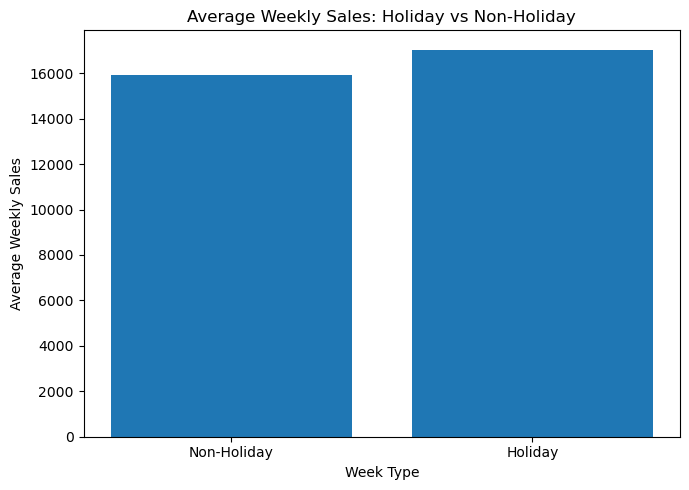

In [50]:
plt.figure(figsize=(7, 5))

plt.bar(
    holiday_avg_sales.index,
    holiday_avg_sales.values
)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()

plt.show()

Observation: Holiday weeks recorded higher average Weekly Sales (approximately 17,036 dollars) than non-holiday weeks (approximately 15,901 dollars). This represents about a 7.1% higher average during holiday weeks. The result indicates an association between holiday periods and higher average sales in this dataset, but it should not be interpreted as evidence that holidays directly caused the increase.

## 7. Weekly Sales Distribution & Outlier Analysis

The distribution of Weekly Sales is examined to understand its spread, skewness, and extreme observations. Statistical outliers are identified using the IQR method and investigated before deciding whether they should be removed.

### 7.1 Weekly Sales Distribution

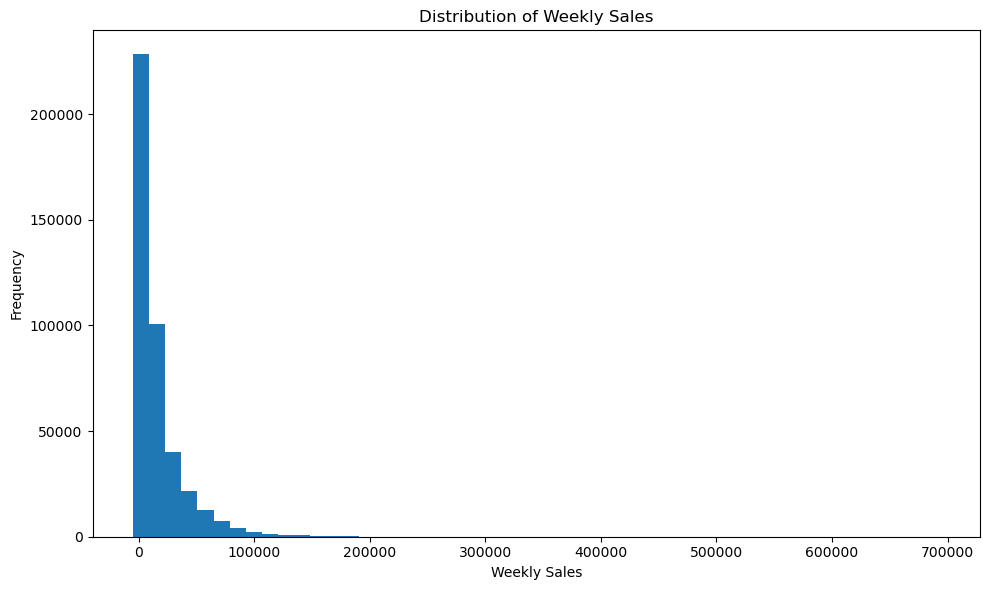

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(
    train["Weekly_Sales"],
    bins=50
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

Observation: The distribution of Weekly Sales is strongly right-skewed, with most observations concentrated at lower-to-moderate sales values and a smaller number of very high sales observations creating a long right tail. These extreme values may represent genuine sales spikes, so they should be investigated rather than automatically removed as outliers.

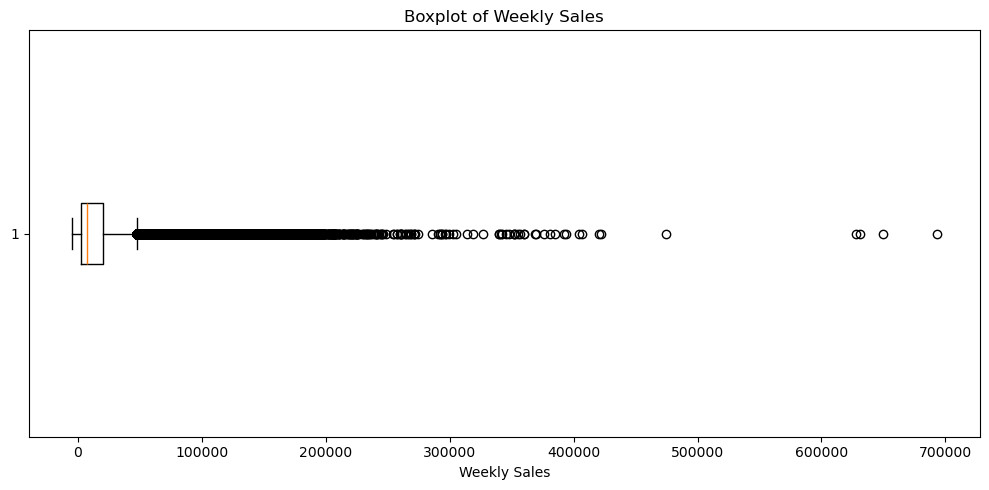

In [52]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    train["Weekly_Sales"],
    vert=False
)

plt.title("Boxplot of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.tight_layout()

plt.show()

Observation: The boxplot confirms that Weekly Sales are right-skewed and contain many high-value outliers above the upper whisker. A small number of negative sales observations are also present. These extreme values were retained because statistical outliers do not necessarily represent data errors and may reflect genuine sales activity.

### 7.2 Investigation of Extreme Sales

In [53]:
train.nlargest(
    10,
    "Weekly_Sales"
)[
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]
]

,Store,Dept,Date,Weekly_Sales,IsHoliday
95373,10,72,2010-11-26,693099.36,1
338013,35,72,2011-11-25,649770.18,1
95425,10,72,2011-11-25,630999.19,1
337961,35,72,2010-11-26,627962.93,1
135665,14,72,2010-11-26,474330.10,1
195088,20,72,2010-11-26,422306.25,1
264390,27,72,2010-11-26,420586.57,1
88428,10,7,2010-12-24,406988.63,0
95377,10,72,2010-12-24,404245.03,0
214432,22,72,2010-11-26,393705.20,1


Observation: The highest Weekly Sales observations are concentrated mainly in Department 72, which appears in 9 of the top 10 records. Seven of the top 10 observations occurred during holiday weeks, with several occurring on November 26, 2010 and November 25, 2011. The highest individual Weekly Sales value was $693,099.36 for Store 10, Department 72. These patterns suggest that the extreme sales values may reflect genuine department- and date-specific sales spikes rather than obvious data errors. Therefore, they were retained in the analysis.

### 7.3 IQR Outlier Detection

In [54]:
Q1 = train["Weekly_Sales"].quantile(0.25)
Q3 = train["Weekly_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[
    (train["Weekly_Sales"] < lower_bound) |
    (train["Weekly_Sales"] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Number of Outliers:", len(outliers))
print("Outlier Percentage:", round(len(outliers) / len(train) * 100, 2), "%")

Q1: 2079.65
Q3: 20205.85
IQR: 18126.2
Lower Bound: -25109.65
Upper Bound: 47395.16
Number of Outliers: 35521
Outlier Percentage: 8.43 %


Outlier Analysis: Using the IQR method, 35,521 Weekly Sales observations (8.43% of the dataset) were classified as statistical outliers, with values above approximately $47,395.16 representing most of the flagged observations. However, inspection of the highest sales records showed that many extreme values are concentrated in specific departments and dates. Therefore, these observations were retained rather than automatically removed, as they may represent genuine retail sales spikes.

## 8. Store Characteristics Analysis

Store-level information is combined with the sales dataset to explore whether store characteristics are associated with Weekly Sales.

In [55]:
train_store = train.merge(
    stores,
    on="Store",
    how="left"
)

train_store.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Month_Name,Type,Size
0,1,1,2010-02-05,24924.50,0,2010,2,February,A,151315
1,1,1,2010-02-12,46039.49,1,2010,2,February,A,151315
2,1,1,2010-02-19,41595.55,0,2010,2,February,A,151315
3,1,1,2010-02-26,19403.54,0,2010,2,February,A,151315
4,1,1,2010-03-05,21827.90,0,2010,3,March,A,151315


In [56]:
train_store[["Store", "Type", "Size"]].head()

,Store,Type,Size
0,1,A,151315
1,1,A,151315
2,1,A,151315
3,1,A,151315
4,1,A,151315


In [57]:
print("Original rows:", train.shape[0])
print("After merge:", train_store.shape[0])

Original rows: 421570
After merge: 421570


### 8.1 Store Size vs Weekly Sales

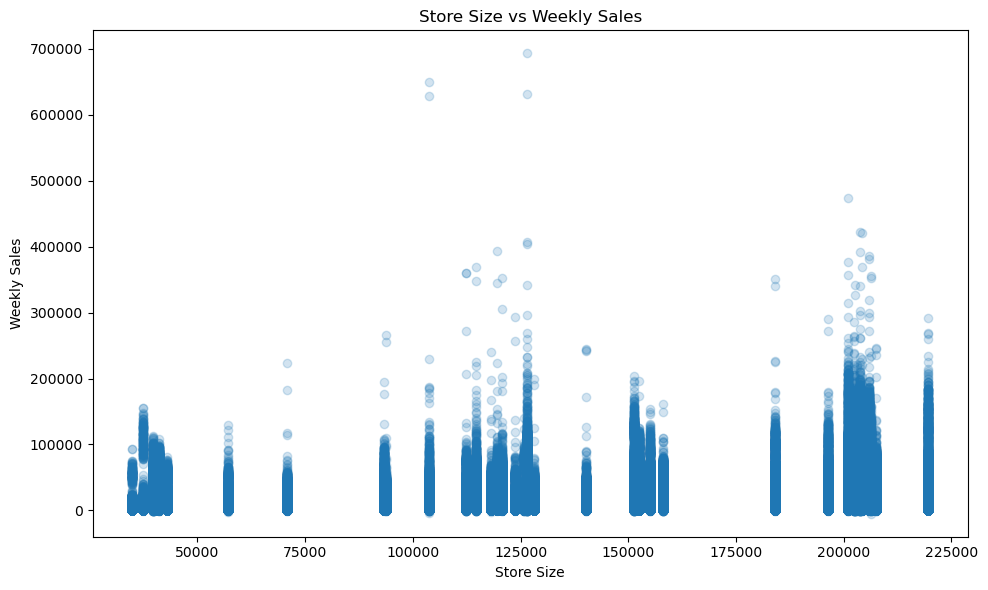

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(
    train_store["Size"],
    train_store["Weekly_Sales"],
    alpha=0.2
)

plt.title("Store Size vs Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")
plt.tight_layout()

plt.show()

Observation: The scatter plot suggests that larger stores tend to have a greater range of Weekly Sales and include more high-sales observations. However, there is substantial variation in sales across stores of similar sizes, indicating that store size alone does not explain sales performance. Other factors such as department, time period, and store characteristics may also contribute to the observed differences.

## 9. External & Economic Factors

The sales dataset is combined with external feature data to examine whether economic and environmental variables are associated with Weekly Sales.

In [59]:
train_features = train.merge(
    features,
    on=["Store", "Date"],
    how="left",
    suffixes=("", "_features")
)

train_features.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Month_Name,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_features
0,1,1,2010-02-05,24924.50,0,2010,2,February,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,1,2010,2,February,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,0,2010,2,February,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,0,2010,2,February,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,0,2010,3,March,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [60]:
print("Original train rows:", train.shape[0])
print("After merge:", train_features.shape[0])

train_features[
    ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
].head()

Original train rows: 421570
After merge: 421570


,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
0,24924.50,42.31,2.572,211.096358,8.106
1,46039.49,38.51,2.548,211.242170,8.106
2,41595.55,39.93,2.514,211.289143,8.106
3,19403.54,46.63,2.561,211.319643,8.106
4,21827.90,46.50,2.625,211.350143,8.106


### 9.1 Correlation with Economic Variables

In [61]:
correlation_columns=[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

correlation_matrix=(
    train_features[correlation_columns]
    .corr()
    .round(3)
)

correlation_matrix
    

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000,-0.002,-0.000,-0.021,-0.026
Temperature,-0.002,1.000,0.144,0.182,0.097
Fuel_Price,-0.000,0.144,1.000,-0.164,-0.034
CPI,-0.021,0.182,-0.164,1.000,-0.300
Unemployment,-0.026,0.097,-0.034,-0.300,1.000


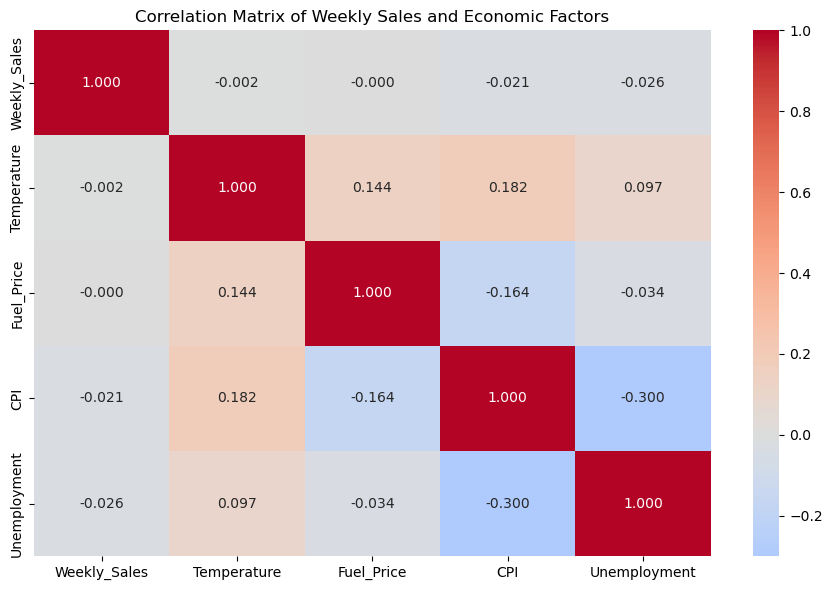

In [62]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Weekly Sales and Economic Factors")
plt.tight_layout()
plt.show()

Observation: Weekly Sales show very weak linear correlations with Temperature (-0.002), Fuel Price (approximately 0.000), CPI (-0.021), and Unemployment (-0.026). None of these variables individually shows a strong linear association with Weekly Sales in the dataset. CPI and Unemployment have a moderate negative correlation with each other (-0.300). These correlations describe associations and should not be interpreted as causal relationships.

## 10. Promotional Markdown Analysis

Promotional Markdown variables are examined for data completeness and their linear relationships with Weekly Sales. Because these variables contain substantial missing data, the results should be interpreted cautiously.

### 10.1 Markdown Missing Values

In [63]:
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

train_features[markdown_columns].isnull().sum()

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

In [64]:
(
    train_features[markdown_columns]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

MarkDown1    64.26
MarkDown2    73.61
MarkDown3    67.48
MarkDown4    67.98
MarkDown5    64.08
dtype: float64

Observation: The MarkDown variables contain substantial missing data, ranging from approximately 64% to 74%. MarkDown2 has the highest missingness at 73.61%. Because the meaning of these missing values is not established, they were not imputed or replaced with zero. Any analysis involving promotional markdowns should therefore be interpreted cautiously.

### 10.2 Markdown Correlation with Weekly Sales

In [65]:
markdown_corr = train_features[
    [
        "Weekly_Sales",
        "MarkDown1",
        "MarkDown2",
        "MarkDown3",
        "MarkDown4",
        "MarkDown5"
    ]
].corr().round(3)

markdown_corr

,Weekly_Sales,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
Weekly_Sales,1.000,0.085,0.024,0.060,0.045,0.090
MarkDown1,0.085,1.000,0.024,-0.108,0.819,0.160
MarkDown2,0.024,0.024,1.000,-0.050,-0.008,-0.007
MarkDown3,0.060,-0.108,-0.050,1.000,-0.071,-0.026
MarkDown4,0.045,0.819,-0.008,-0.071,1.000,0.108
MarkDown5,0.090,0.160,-0.007,-0.026,0.108,1.000


Observation: The available Markdown variables show only weak positive correlations with Weekly Sales. MarkDown5 has the highest correlation with Weekly Sales (0.090), followed by MarkDown1 (0.085), but neither indicates a strong linear relationship. MarkDown1 and MarkDown4 are strongly positively correlated (0.819). Because approximately 64%–74% of the Markdown data is missing, these relationships should be interpreted cautiously. Correlation does not imply causation.

## 11. Department Sales Variability

Department-level sales variability is examined using the mean, standard deviation, and coefficient of variation (CV). This helps identify departments whose Weekly Sales fluctuate substantially over time.

### 11.1 Variability by Department

In [66]:
dept_variability = (
    train.groupby("Dept")["Weekly_Sales"]
    .agg(["mean", "std"])
    .round(2)
)

dept_variability["cv"] = (
    dept_variability["std"] /
    dept_variability["mean"]
)

dept_variability.sort_values(
    "std",
    ascending=False
).head(10)

,mean,std,cv
Dept,,,
92,75204.87,49413.73,0.657055
72,50566.52,44710.98,0.884201
95,69824.42,38200.54,0.547094
90,45232.08,32462.02,0.717677
7,24161.24,27985.08,1.158263
91,33687.91,26247.46,0.779136
94,33405.88,25405.56,0.760512
2,43607.02,25176.76,0.577356
38,61090.62,23966.91,0.392317


Observation: Department 92 recorded the highest absolute sales variability, with a standard deviation of approximately 49,414 dollars, followed by Department 72 at approximately 44,711 dollars. Department 7 showed particularly high relative variability, with a coefficient of variation (CV) of approximately 1.16. In contrast, Department 38 had relatively high average sales but a lower CV of approximately 0.39, indicating comparatively more stable sales relative to its mean.

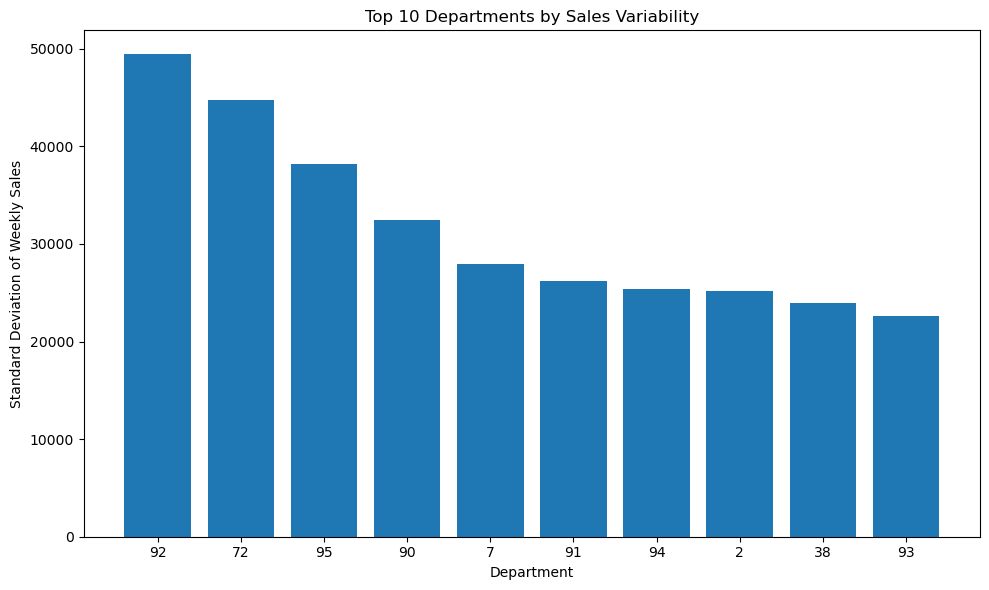

In [67]:
top_variable_depts = (
    dept_variability
    .sort_values("std", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_variable_depts.index.astype(str),
    top_variable_depts["std"]
)

plt.title("Top 10 Departments by Sales Variability")
plt.xlabel("Department")
plt.ylabel("Standard Deviation of Weekly Sales")
plt.tight_layout()

plt.show()

## 12. Key EDA Findings

- The dataset contains **421,570 sales records** covering **45 stores and 81 departments**, from February 2010 through October 2012.
- No missing values or duplicate records were identified in the main training dataset. Negative and zero sales were retained because they could not be confirmed as data errors.
- Total sales increased from approximately **2.29 billion dollars in 2010 to 2.45 billion dollars in 2011**. The 2012 total is incomplete because the dataset ends in October.
- Holiday weeks recorded approximately **7.1% higher average Weekly Sales** than non-holiday weeks.
- Weekly Sales are strongly right-skewed. The IQR method identified **35,521 observations (8.43%)** as statistical outliers, but investigation showed that many extreme values follow identifiable department and date patterns, so they were retained.
- **Department 72** appeared frequently among the highest individual Weekly Sales observations.
- Temperature, Fuel Price, CPI, and Unemployment showed **very weak linear correlations** with Weekly Sales.
- Promotional Markdown variables contained substantial missing data (**approximately 64%–74%**) and showed only weak correlations with Weekly Sales.
- Department sales variability differs considerably. **Department 92** showed the highest absolute variability among the departments examined, while **Department 7** showed particularly high relative variability.
- Store size was associated with a wider range of sales values among larger stores, but store size alone does not explain sales performance.


## 13. Conclusion

The exploratory data analysis identified meaningful variation in Walmart sales across time, stores, departments, and holiday periods. The analysis also demonstrated that statistical outliers should not automatically be treated as data errors, as many extreme sales observations were associated with specific departments and dates.

The external economic and promotional variables examined did not show strong linear relationships with Weekly Sales at the observation level. Overall, this Python EDA provides a validated and well-understood dataset for the project's subsequent **SQL business analysis and Power BI dashboard development**.